# 'Dissipation as a resource for Quantum Reservoir Computing' analysis
The aim of this notebook is to reproduce the results of the paper 'Dissipation as a resource for Quantum Reservoir Computing' by Antonio Sannia et. al, and to further investigate the methodology of the paper

## 1. Imports

In [1]:
from qsim.dynamics import Dynamics, RK4Propagator, GKSLGenerator, ExponentialPropagator, HamiltonianGenerator, LiouvillianGenerator
from qsim.lin_alg import sigmaX, sigmaY, sigmaZ, I, TOperator, sigmaMinus, Operator, Vector
from qsim.logging import Logger
from qsim.state import Detector, DensityMatrix
from qsim.lin_alg.transforms import vectorise, unvectorise
from numbers import Real
from functools import reduce
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

## 2. Time Series Configuration

In [2]:
from typing import Protocol


class Series(Protocol):

    def __call__(self, index: int) -> Real: ...

class TimeSeries:
    def __init__(self, s: Series, delta_t: Real):
        self._s = s
        self._delta_t = delta_t

    def __call__(self, t) -> Real:
        index = int((t + 10e-10) // self._delta_t)
        return self._s(index)

In [3]:
class UniformRandomSeries(Series):

    def __init__(self, n):
        self._s = np.random.rand(n)

    def __call__(self, index: int):
        if index >= self._s.shape[0]:
            raise ValueError(f'Index {index} exceeds series length of {self._s.shape[0]}')
        return self._s[index]

In [4]:
s = UniformRandomSeries(100)

In [5]:
ts = TimeSeries(s, 0.3)

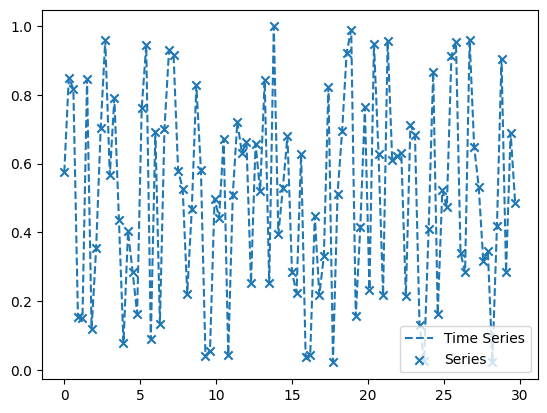

In [6]:
times = np.linspace(0,29.7, 100)
fig, ax = plt.subplots()
ax.plot(times, [ts(t) for t in times], label='Time Series', linestyle = '--')
ax.scatter(0.3 * np.arange(100), [s(index) for index in np.arange(100)], label='Series', marker='x')
ax.legend()
plt.show()

## 3. Global Parameters and functions

Global parameters and time series input

In [7]:
N = 3
J_s = 1

s = UniformRandomSeries(3500)

In [8]:
state = np.zeros(shape=(2**N, 2**N))
state[0][0] = 1
rho0 = DensityMatrix(state)

Constructing transverse ising Hamiltonian

In [9]:
def transIsingH(h):
    ops = []
    for j in range(N):
        ops.append(h * TOperator.from_static(sigmaZ).changeHilbertSpace((2,)*N, send_to_sites=(j,)))
        for i in range(j):
            ops.append(np.random.uniform(-J_s, J_s) * sigmaX.tensor(sigmaX).changeHilbertSpace((2,) * N, send_to_sites=(i,j), base_dims=(2,2)))
            
    return reduce(lambda x,y:x+y, ops)

Standard logging setup

In [10]:
def singleQubitDetector(node: int, op: Operator):
    return Detector(op, dims=(2,) * N, target_sites=(node,))

def dualQubitDetector(node1: int, op1: Operator, node2: int, op2: Operator):
    return Detector(op1.tensor(op2), dims=(2,) * N, target_sites=(node1, node2))

Setting up loggers for first and second moment Pauli observables

In [11]:
def getLogger():
    detectors = []
    paulis = [sigmaX, sigmaY, sigmaZ]

    for i in range(N):
        for pauli in paulis:
            detectors.append(singleQubitDetector(i, pauli))

    for pauli in paulis:
        for i in range(N):
            for j in range(i):
                if i != j:
                    detectors.append(dualQubitDetector(i, pauli, j, pauli))
    
    log = Logger(detectors)
    return log

Dynamics check function

In [12]:
def checkLegit(state: DensityMatrix, t):
    if not state.isLegitimate():
        print('Invalid Density Matrix')
        if round(state.trace().real,5) != 1:
            print(f'Trace: {round(state.trace().real,5)}')
        if not state.isSelfAdjoint():
            print('State not self-adjoint')
        if not state.isSemiPositive():
            print(f'State min eig: {min(np.linalg.eigvals(state.matrix))}')

## 4. Fuji-Nakajima Model

### 4.1 FN Dynamics Setup

Defining relevant parameter combinations

In [13]:
fn_params = [(0.1, 10), (1, 1)]

Creating dynamics generator

In [14]:
dynamics_fn = []

for h_fn, delta_t_fn in fn_params:
    prop_fn = ExponentialPropagator(callbacks=[checkLegit])
    gen_fn = HamiltonianGenerator(transIsingH(h_fn)(0))

    dyn_fn = Dynamics(prop_fn, gen_fn)
    log_fn = getLogger()
    dyn_fn.addCallback(log_fn.log)
    dynamics_fn.append((dyn_fn, log_fn, delta_t_fn))

Function to encode timeseries value into state

In [15]:
def fnEncode(state: DensityMatrix, s: Real):
    state = state.partialTrace(dims=(2,)*N, reduce_to_sites=(1,2,3,4))
    state = DensityMatrix(np.array([[1-s, (s-s**2)**0.5], [(s-s**2)**0.5, s]])).tensor(state)
    return state

### 4.2 FN Sample Evolution

In [16]:
dyn_fn, log_fn,delta_t_fn = dynamics_fn[0]
log_fn.clear()
num_steps = 10
steps = np.arange(1, num_steps + 1)
state_t = fnEncode(rho0, s(0))
t0 = 0
for step in tqdm(steps):
    num_sub_steps = 30
    ts = delta_t_fn/num_sub_steps
    for sub_step in range(num_sub_steps):
        state_t = dyn_fn.evolve(state_t, ts=[t0+ts], t0=t0)
        t0 += ts
    state_t = fnEncode(state_t, s(step))

ValueError: axes don't match array

ValueError: x and y must have same first dimension, but have shapes (300,) and (0,)

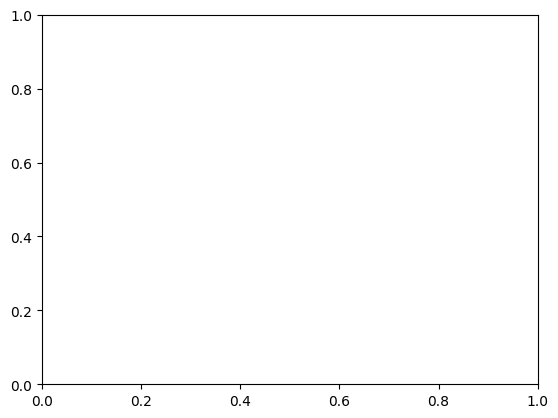

In [ ]:
log_fn = dynamics_fn[0][1]

fig, ax1 = plt.subplots()

measure_times = ts * np.arange(1, num_steps * num_sub_steps + 1)

# First y-axis
ax1.plot(measure_times, log_fn.observable_log[log_fn._detectors[0]].values())
ax1.set_xlabel("Time")
ax1.set_ylabel("sigma z")

# Second y-axis
ax2 = ax1.twinx()
ax2.plot(delta_t_fn*steps, [s(t) for t in steps], linestyle='--', color='r')
ax2.set_ylabel("s_k")

plt.show()

### 4.3 FN Full Evolution

In [17]:
for dyn_fn, log_fn, delta_t_fn in dynamics_fn:
    log_fn.clear()
    num_steps = 3000
    steps = np.arange(1, num_steps + 1)
    state_t = fnEncode(rho0, s(0))
    t0 = 0
    for step in tqdm(steps):
        state_t = dyn_fn.evolve(state_t, ts=[t0+delta_t_fn], t0=t0)
        t0 += delta_t_fn
        state_t = fnEncode(state_t, s(step))

ValueError: axes don't match array

## 5. Continuous Dissipation Model

### 5.1 CD Dynamics Setup

Defining relevant parameter combinations

In [18]:
cd_params = [(0.1, 10, 1), (0.01, 10, 0.1), (0.01, 10, 0.01), (0.01, 1, 0.1)]

Constructing Hamiltonian and jump operators

In [19]:
def variableXDrive(node: int, s_k: Series, h: float):
    H: TOperator =  (lambda t: h * (1+s_k(t))) * TOperator.from_static(sigmaX)
    return H.changeHilbertSpace((2,)*N, send_to_sites=(node,))

In [20]:
def dampingChannel(node: int, gamma: float):
    L: Operator = sigmaMinus
    return (gamma**0.5) * L.changeHilbertSpace((2,)*N, send_to_sites=(node,))

Setting up dynamics, including constructing time series, setting up Hamiltonian with drive and damping and configuring logging

In [21]:
dynamics_cd = []

for h_cd, delta_t_cd, gamma in cd_params:
    H_locals = []
    Ls = []
    s_k = TimeSeries(s, delta_t_cd)

    for i in range(N):
        H_locals.append(variableXDrive(i, s_k, h_cd))
        Ls.append(dampingChannel(i, gamma))

    H_cd = reduce(lambda x,y :x+y, H_locals + [transIsingH(h_cd)])

    prop_cd = RK4Propagator(ts=0.05, callbacks=[checkLegit])
    gen_cd = GKSLGenerator(H_cd, Ls)

    dyn_cd = Dynamics(prop_cd, gen_cd)

    log_cd = getLogger()
    dyn_cd.addCallback(log_cd.log)
    dynamics_cd.append((dyn_cd, log_cd, (h_cd, delta_t_cd, gamma)))

In [89]:
h_cd, delta_t_cd, gamma

(1, 10, 1)

In [191]:
h_cd, delta_t_cd, gamma = cd_params[0]
h_cd = 0.5
H_locals = []
Ls = []
s_k = lambda t: 0

for i in range(N):
    H_locals.append(variableXDrive(i, s_k, h_cd))
    Ls.append(dampingChannel(i, gamma))

s_k2 = TimeSeries(s, delta_t_cd)
H_c = reduce(lambda x,y :x+y, H_locals + [transIsingH(h_cd)])
H_x = reduce(lambda x,y :x+y, H_locals)

In [192]:
gen_c = GKSLGenerator(H_c, Ls)
gen_x = GKSLGenerator(H_x)
gen_t = GKSLGenerator(H_c + s_k2 * H_x, Ls)

In [193]:
l_c = LiouvillianGenerator.fromGKSL(gen_c)
l_x = LiouvillianGenerator.fromGKSL(gen_x)
l_t = LiouvillianGenerator.fromGKSL(gen_t)

In [194]:
np.allclose((l_c.L(0) + s_k2(10) * l_x.L(0)).matrix, l_t.L(10).matrix)

True

In [195]:
prop = RK4Propagator(ts = 0.005)
dyn = Dynamics(prop, gen_t)

In [196]:
z = sigmaZ.changeHilbertSpace((2,) * N, (0,))
z_vec = vectorise(z)

In [197]:
z_eff = dyn.evolveOperator(z, ts=[0], t0=delta_t_cd-0.0001)

In [198]:
z_vec_eff = vectorise(z_eff)

In [199]:
import numpy as np
from scipy.linalg import expm

def exp_series_coeffs(A, B, order):
    """
    Compute coefficients of e^{A + sB} up to s^order.

    Returns list [F0, F1, ..., F_order] where

        e^{A+sB} = F0 + s F1 + s^2/2! F2 + ...

    Fk = d^k/ds^k exp(A+sB) evaluated at s=0.
    """

    n = A.shape[0]
    dim = (order + 1) * n

    M = np.zeros((dim, dim), dtype=A.dtype)

    for i in range(order + 1):
        M[i*n:(i+1)*n, i*n:(i+1)*n] = A

        if i < order:
            M[i*n:(i+1)*n, (i+1)*n:(i+2)*n] = B

    EM = expm(M)

    coeffs = []

    for k in range(order + 1):
        block = EM[:n, k*n:(k+1)*n]
        coeffs.append(block)

    return coeffs

def exp_approx(coeffs, s):
    result = np.zeros_like(coeffs[0])
    for k,C in enumerate(coeffs):
        result += (s**k) * C
    return result

In [200]:
coeffs = exp_series_coeffs(delta_t_cd * l_c.L(0).hConj().matrix, delta_t_cd * l_x.L(0).hConj().matrix, order=30)

In [201]:
import math
est_expA = exp_approx(coeffs, s_k2(0))

In [221]:
norms = []
orders = range(1,20)
coeffs1 = exp_series_coeffs(delta_t_cd * l_c.L(0).hConj().matrix, delta_t_cd * l_x.L(0).hConj().matrix, order=max(orders))
for t in [0,10,20,30]:
    norms.append([])
    targ=expm(delta_t_cd*(l_c.L(0).hConj() + s_k2(t) * l_x.L(0).hConj()).matrix)
    for i in tqdm(orders):
        coeffs = coeffs1[:i]
        est_expA = exp_approx(coeffs, s_k2(t))
        norms[-1].append(np.linalg.norm(targ -est_expA))

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

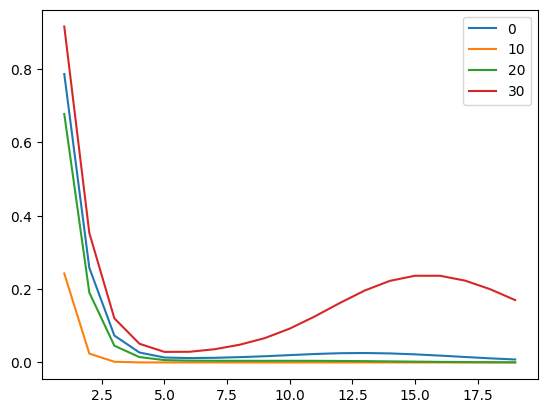

In [222]:
plt.plot(orders, np.array(norms).T)
plt.legend([0,10,20,30])

In [223]:
norms = []

for t in [0, 10, 20, 30]:
    norms.append([])
    targ=expm(delta_t_cd*(l_c.L(0).hConj() + s_k2(t + 10) * l_x.L(0).hConj()).matrix) @ expm(delta_t_cd*(l_c.L(0).hConj() + s_k2(t) * l_x.L(0).hConj()).matrix)
    for i in orders:
        
        est_expA1 = exp_approx(coeffs1[:i], s_k2(t))
        est_expA2 = exp_approx(coeffs1[:i], s_k2(t+10))

        est_expA = est_expA2 @ est_expA1
        norms[-1].append(np.linalg.norm(est_expA - targ))

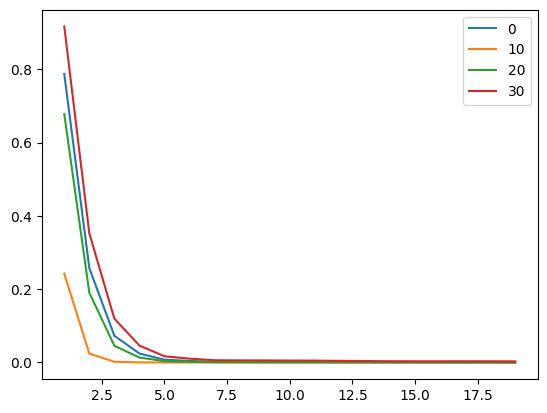

In [225]:
plt.plot(orders, np.array(norms).T)
plt.legend([0,10,20,30])

In [ ]:
from scipy.linalg import expm
np.allclose(z_vec_eff.matrix,  @ z_vec.matrix, rtol=0.0001)

True

### 5.2 CD Sample Evolution

In [84]:
n_steps = 500

for dyn_cd, log_cd, params in dynamics_cd:
    s_k = TimeSeries(s, params[1])

    log_cd.clear()

    measure_times = 0.01*params[1]*(np.arange(501, n_steps + 501))
    dyn_cd.evolve(rho0, ts=measure_times, verbose=1)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

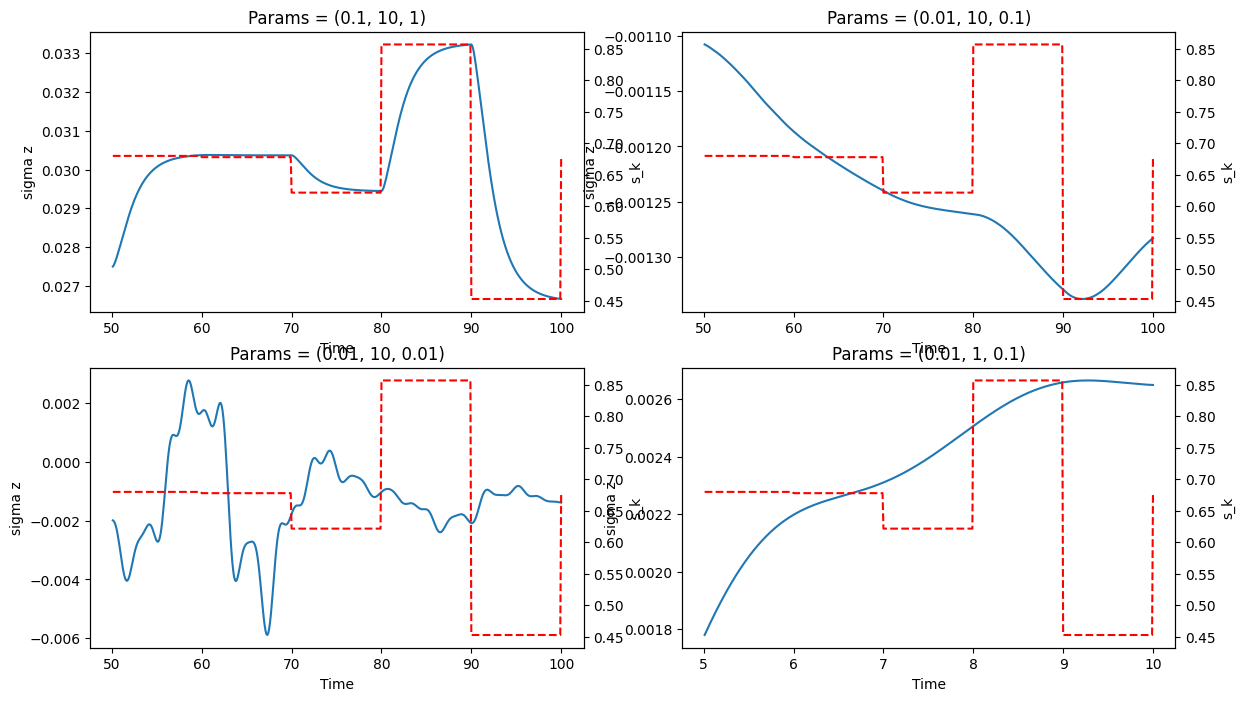

In [85]:
fig, axs = plt.subplots(2,2, figsize=(14,8))

# First y-axis
for i in range(2):
    for j in range(2):
        ax = axs[i][j]
        dyn_cd, log_cd, params = dynamics_cd[2*i + j]
        s_k = TimeSeries(s, params[1])
        measure_times = 0.01*params[1]*(np.arange(501, n_steps + 501))
        ax.plot(measure_times, log_cd.observable_log[log_cd._detectors[3]].values())
        ax.set_xlabel("Time")
        ax.set_ylabel("sigma z")

        # Second y-axis
        ax2 = ax.twinx()
        ax2.plot(measure_times, [s_k(t) for t in measure_times], linestyle='--', color='r')
        ax2.set_ylabel("s_k")

        ax.set_title(f'Params = {params}')

#### 5.2.1 CD Evolution in Heisenberg Picture

In [86]:

h_cd = .1
gamma = .5
delta_t_cd = 1

H_locals = []
Ls = []
s_k = TimeSeries(s, delta_t_cd)

for i in range(N):
    H_locals.append(variableXDrive(i, s_k, h_cd))
    Ls.append(dampingChannel(i, gamma))

H_cd = reduce(lambda x,y :x+y, H_locals + [transIsingH(h_cd)])

prop_cd = RK4Propagator(ts=0.02)
gen_cd = GKSLGenerator(H_cd, Ls)

dyn_cd = Dynamics(prop_cd, gen_cd)

log_cd = Logger(log_state=True)
dyn_cd.addCallback(log_cd.log)

In [87]:
n_steps = 5000

observable = sigmaZ.changeHilbertSpace((2,)*N, send_to_sites=(0,))
observable = sigmaX.tensor(sigmaX).changeHilbertSpace((2,)*N, send_to_sites=(0,2), base_dims=(2,2))


log_cd.clear()

measure_times = 0.01*delta_t_cd*(np.arange(501, n_steps + 501))
final = dyn_cd.evolveOperator(observable, ts=sorted(measure_times,reverse=True), t0=max(measure_times), verbose=1)

  0%|          | 0/5000 [00:00<?, ?it/s]

### 5.3 CD Full Evolution

In [88]:
for dyn_cd, log_cd, params in dynamics_cd:
    log_cd.clear()
    measure_times = params[1]*(np.arange(1, 3001))
    dyn_cd.evolve(rho0, ts=measure_times, verbose=1)

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

## 6. CD QRC Analysis

Defining training and testing data ranges

In [89]:
tr_idxs = np.arange(1000,2000)
te_idxs = np.arange(2000, 3000)

### 6.1 Target Functions

#### 6.1.1 STM function

In [90]:
def STM(tau: int, s: Series):
    return lambda t: s(t-tau)

In [91]:
import math


def STM_exp(tau: int, s: Series):
    return lambda t: math.e**s(t-tau)

Visualising STM

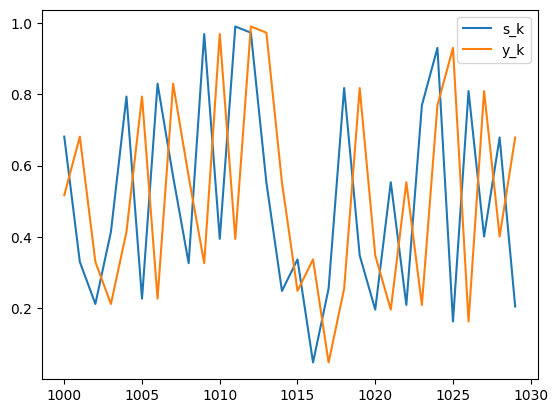

In [93]:
tau=1
y_k = STM(tau, s)

plt.plot(tr_idxs[:30], [s(i) for i in tr_idxs[:30]], label = 's_k')
plt.plot(tr_idxs[:30], [y_k(i) for i in tr_idxs[:30]], label = 'y_k')
plt.legend()

#### 6.1.2 NARMA function

In [94]:
def narma(n: int, s_k: Series):
    def narma_n(k: int, depth: int = 10, computed: dict = None):
        if not computed:
            computed = {}
        if depth > 0:
            depth -= 1
            if k-1 not in computed.keys():
                computed[k-1] = narma_n(k-1, depth, computed)
            for j in range(1, n + 1):
                if k-j not in computed.keys():
                    computed[k-j] = narma_n(k-j, depth, computed) 
            return computed[k-1]*(0.3 + 0.05 * sum([computed[k-j] for j in range(1, n + 1)])) + 1.5 * s_k(k-n)*s_k(k-1) + 0.1
        else:
            return 0
    return narma_n

Assessing necessary depth - 40 appears to be sufficient for n <= 20

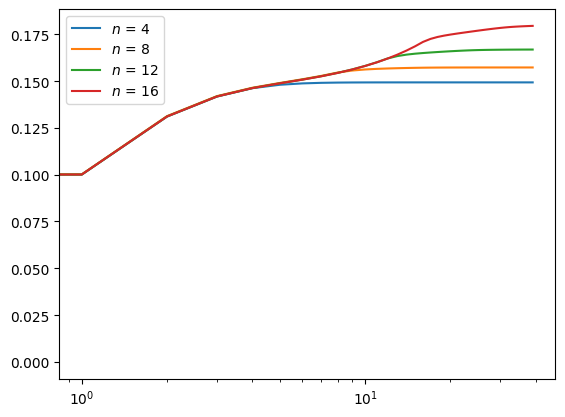

In [95]:
depths = np.arange(40)

for n in np.arange(1, 5) * 4:
    narma_n = narma(n, lambda i: s(i)/50)
    plt.plot(depths, [narma_n(1000, depth) for depth in (depths)], label=r'$n$ = ' + str(n))

plt.legend()
plt.xscale('log')

Visualising segment of NARMA for n = 10

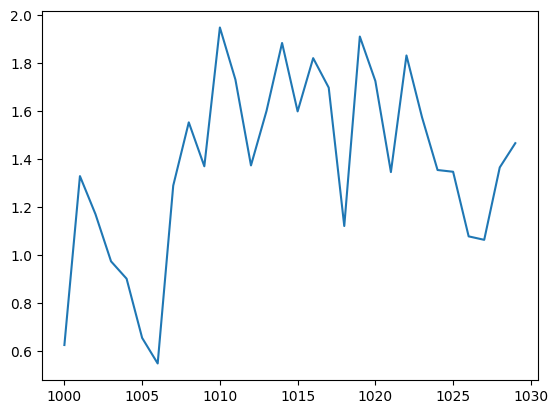

In [96]:
narma_10 = narma(10, s)
plt.plot(tr_idxs[:30], [narma_10(i) for i in tr_idxs[:30]])

#### 6.1.3 Parity Function

In [97]:
def parity(tau, s):
    return lambda k: sum([s(k-j) for j in range(1, tau+1)]) % 2

Visualising parity function

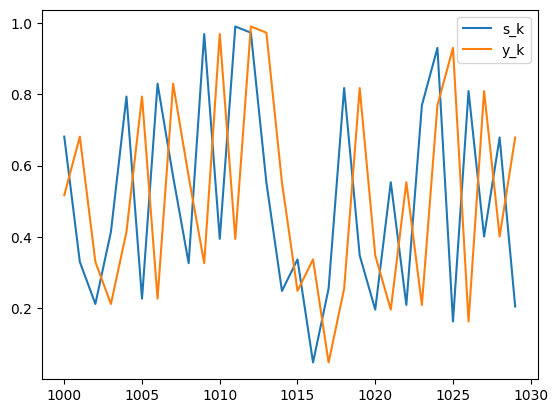

In [98]:
y_k = parity(tau, s)

plt.plot(tr_idxs[:30], [s(i) for i in tr_idxs[:30]], label = 's_k')
plt.plot(tr_idxs[:30], [y_k(i) for i in tr_idxs[:30]], label = 'y_k')
plt.legend()

#### 6.1.4 Polynomial Task

In [99]:
def polynomial(n, s, order = 1):
    return lambda k: reduce(lambda x,y: x * y, [s(k-j)**order for j in range(1, n+1)])

In [100]:
def polynomial_exp(n, s):
    return lambda k: reduce(lambda x,y: x * y, [math.e**s(k-j) for j in range(1, n+1)])

Visualising polynomial function

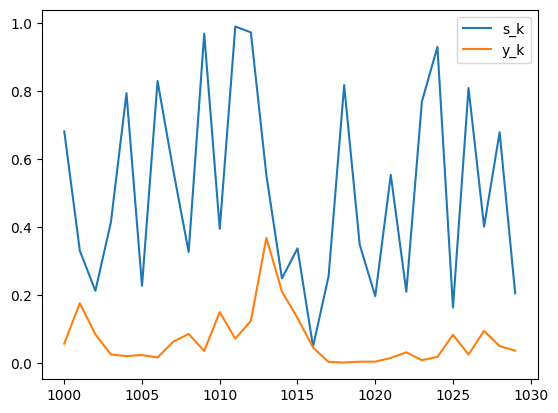

In [101]:
y_k = polynomial(4, s)

plt.plot(tr_idxs[:30], [s(i) for i in tr_idxs[:30]], label = 's_k')
plt.plot(tr_idxs[:30], [y_k(i) for i in tr_idxs[:30]], label = 'y_k')
plt.legend()

#### 6.1.5 Tomography task

In [102]:
import numpy as np

def density_matrix_to_vec(rho: np.ndarray) -> np.ndarray:
    """
    Flatten a Hermitian density matrix into a 1D real vector containing
    all unique real and imaginary parts.

    Layout of the returned vector:
        [ diag (N),
          Re(upper off-diagonal) (N*(N-1)/2),
          Im(upper off-diagonal) (N*(N-1)/2) ]

    Parameters
    ----------
    rho : np.ndarray, shape (N, N), complex
        Hermitian density matrix.

    Returns
    -------
    vec : np.ndarray, shape (N**2,), float
        Flattened representation.
    """
    rho = np.asarray(rho)
    if rho.ndim != 2 or rho.shape[0] != rho.shape[1]:
        raise ValueError("rho must be a square 2D array")

    N = rho.shape[0]

    # Optional sanity check for Hermiticity
    if not np.allclose(rho, rho.conj().T):
        raise ValueError("rho is not Hermitian within numerical tolerance")

    # Diagonal (purely real for a density matrix)
    diag = rho.diagonal().real

    # Upper-triangular off-diagonal entries
    iu = np.triu_indices(N, k=1)
    upper = rho[iu]
    real_upper = upper.real
    imag_upper = upper.imag

    # Concatenate into a single real vector
    vec = np.concatenate([diag, real_upper, imag_upper]).astype(float)
    return vec


def vec_to_density_matrix(vec: np.ndarray) -> np.ndarray:
    """
    Reconstruct a Hermitian matrix from the flattened real vector produced
    by `density_matrix_to_vec`.

    Parameters
    ----------
    vec : np.ndarray, shape (N**2,), float
        Flattened representation.

    Returns
    -------
    rho : np.ndarray, shape (N, N), complex
        Reconstructed Hermitian matrix.
    """
    vec = np.asarray(vec, dtype=float).ravel()

    # Infer dimension N from length N**2
    N_float = np.sqrt(vec.size)
    N = int(round(N_float))
    if N * N != vec.size:
        raise ValueError("Length of vec must be a perfect square (N**2).")

    # Number of unique off-diagonal entries in the upper triangle
    K = N * (N - 1) // 2
    expected_len = N + 2 * K
    if vec.size != expected_len:
        raise ValueError(
            f"Invalid vector length {vec.size} for any Hermitian N; "
            f"expected N + 2 * N*(N-1)/2 = N**2."
        )

    # Slice out components
    diag = vec[:N]
    real_upper = vec[N:N + K]
    imag_upper = vec[N + K:]

    # Build matrix
    rho = np.zeros((N, N), dtype=complex)
    np.fill_diagonal(rho, diag)

    iu = np.triu_indices(N, k=1)
    rho[iu] = real_upper + 1j * imag_upper
    # Fill lower triangle by Hermitian symmetry
    rho[(iu[1], iu[0])] = rho[iu].conj()

    return rho



In [103]:
def tomography(n, s):
    def tomography_n(k):
        s_vals = [s(k - j) for j in range(1, n+1)]
        state = DensityMatrix(np.array([[1-s_vals[0], (s_vals[0]-s_vals[0]**2)**0.5], [(s_vals[0]-s_vals[0]**2)**0.5, s_vals[0]]]))

        for s_val in s_vals[1:]:
            state = state.tensor(DensityMatrix(np.array([[1-s_val, (s_val-s_val**2)**0.5], [(s_val-s_val**2)**0.5, s_val]])))

        return density_matrix_to_vec(state.state)
    return tomography_n

### 6.2 Evaluating Performance

In [104]:
class LinearRegression:

    def fit(self, x, y):
        vals = np.linalg.pinv(np.vstack([x.T, np.ones(x.shape[0])])).T @ y
        self.coeff = vals[:-1]
        self.c = vals[-1] 
        return self

    def predict(self, x):
        return x @ self.coeff + self.c

In [105]:
x_tr_fn = {}
x_tr_cd = {}

x_te_fn = {}
x_te_cd = {}

for params, dynamics in zip(fn_params, dynamics_fn):
    log_fn = dynamics[1]
    x_fn = np.vstack([list(log_fn.observable_log[detector].values()) for detector in log_fn._detectors])
    x_tr_fn[params] = x_fn.T[tr_idxs[0]:tr_idxs[-1]+1]
    x_te_fn[params] = x_fn.T[te_idxs[0]:te_idxs[-1]+1]


for params, dynamics in zip(cd_params, dynamics_cd):
    log_cd = dynamics[1]
    x_cd = np.vstack([list(log_cd.observable_log[detector].values()) for detector in log_cd._detectors])
    x_tr_cd[params] = x_cd.T[tr_idxs[0]:tr_idxs[-1]+1]
    x_te_cd[params] = x_cd.T[te_idxs[0]:te_idxs[-1]+1]

In [106]:
def getYData(target):
    y_tr = np.array([target(t) for t in tr_idxs])
    y_te = np.array([target(t) for t in te_idxs])
    return y_tr, y_te

In [107]:
def memory_capacity(y_true, y_pred):

    # Remove mean (important)
    yt = y_true - np.mean(y_true)
    yp = y_pred - np.mean(y_pred)

    cov = np.mean(yt * yp)
    var_true = np.var(yt)
    var_pred = np.var(yp)


    Cd = (cov ** 2) / (var_true * var_pred)

    return Cd

In [108]:
def visualisePerformance(reg_fn, reg_cd, y_te, params_fn, params_cd, length=50):
    fig, ax = plt.subplots(dpi=150)
    ax.plot(reg_fn.predict(x_te_fn[params_fn][:length]), label='FN Predicted', linestyle = '--')
    ax.plot(reg_cd.predict(x_te_cd[params_cd][:length]), label='CD Predicted', linestyle = '--')
    ax.plot(y_te[:length], label='True')
    ax.legend()
    ax.set_xlabel('k')

    print(f'FN Capacity: {memory_capacity(y_te, reg_fn.predict(x_te_fn[params_fn]))}')
    print(f'CD Capacity: {memory_capacity(y_te, reg_cd.predict(x_te_cd[params_cd]))}')

    return fig, ax

In [109]:
class RCTask:

    def __init__(self, func):
        self._func = func

    def plotTimeSeriesEstimate(self, func_param, fn_params, cd_params):
        func = self._func(func_param, s)
        y_tr_stm, y_te_stm = getYData(func)
        reg_fn_stm = LinearRegression().fit(x_tr_fn[fn_params], y_tr_stm)
        reg_cd_stm = LinearRegression().fit(x_tr_cd[cd_params], y_tr_stm)
        return visualisePerformance(reg_fn_stm, reg_cd_stm, y_te_stm, fn_params, cd_params)
    
    def plotPerfVsSettings(self, settings):
        scores = []

        for setting in settings:
            func = self._func(setting, s)
            y_tr, y_te = getYData(func)

            max_fn_score = 0
            for params in fn_params:
                reg_fn = LinearRegression().fit(x_tr_fn[params], y_tr)
                y_pred_fn = reg_fn.predict(x_te_fn[params])
                c_fn = memory_capacity(y_te, y_pred_fn)
                if c_fn > max_fn_score:
                    max_fn_score = c_fn

            max_cd_score = 0

            for params in cd_params:
                reg_cd = LinearRegression().fit(x_tr_cd[params], y_tr)
                y_pred_cd = reg_cd.predict(x_te_cd[params])
                c_cd = memory_capacity(y_te, y_pred_cd)
                if c_cd > max_cd_score:
                    max_cd_score = c_cd

            scores.append([max_fn_score, max_cd_score])

        fig, ax = plt.subplots(dpi=150)
        ax.plot(settings, np.array(scores))
        ax.legend(['FN Model', 'CD Model'])
        ax.set_ylabel('C')
        return fig, ax


In [110]:
def getCapacities(reg_fn, reg_cd, y_te):
    capacities_fn = {}
    capacities_cd = {}

    for key, value in x_te_fn.items():
        capacities_fn[key] = memory_capacity(y_te, reg_fn.predict(value))
    
    for key, value in x_te_cd.items():
        capacities_cd[key] = memory_capacity(y_te, reg_cd.predict(value))

    return capacities_fn, capacities_cd


#### 6.2.1 Performance on STM task

In [111]:
def stmParamsCd(tau):
    if tau < 2:
        cd_tau_params = (0.1, 10, 1)
    elif tau < 6:
        cd_tau_params = (0.01, 10, 0.1)
    elif tau < 16:
        cd_tau_params = (0.01, 10, 0.01)
    elif tau <= 20:
        cd_tau_params = (0.01, 1, 0.1)
    else:
        raise ValueError(f'Undefined for $\tau$ = {tau}')
    return cd_tau_params

In [112]:
def stmParamsFn(tau):
    if tau < 5:
        fn_tau_params = (0.1, 10)
    else:
        fn_tau_params = (1,1)
    return fn_tau_params

In [113]:
stm_task = RCTask(STM_exp)

In [114]:
tau = 10

fn_tau_params = stmParamsFn(tau)
cd_tau_params = stmParamsCd(tau)

FN Capacity: 0.2951123014756862
CD Capacity: 0.9594211969009779


Text(0, 0.5, '$y_k$')

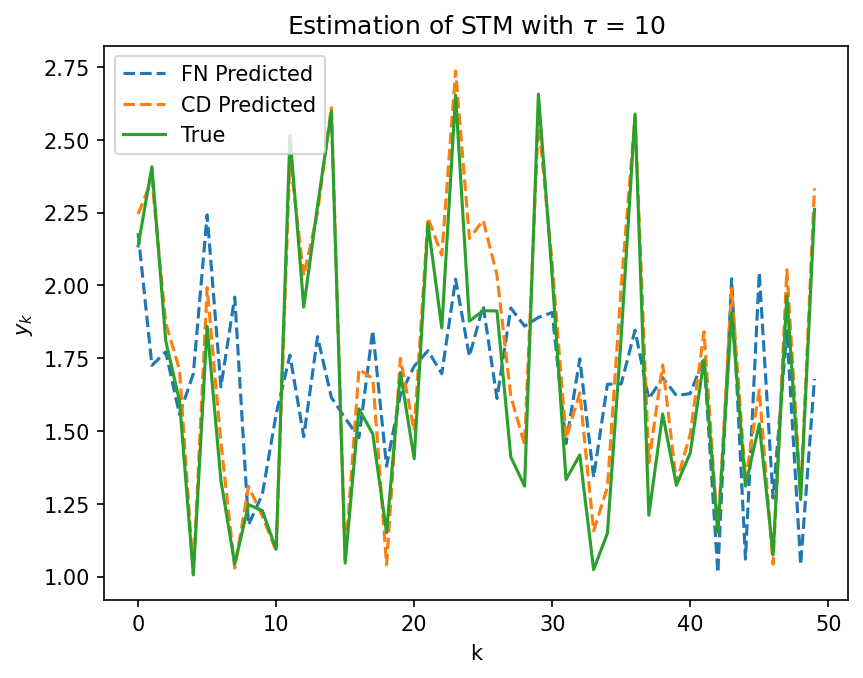

In [115]:
fig, ax = stm_task.plotTimeSeriesEstimate(tau, fn_tau_params, cd_tau_params)
ax.set_title(r'Estimation of STM with $\tau$ = ' + f'{tau}')
ax.set_ylabel(r'$y_k$')

Visualising score over range of tau

In [116]:
taus = np.arange(1, 21)

Text(0.5, 1.0, 'STM performance as a function of time delay')

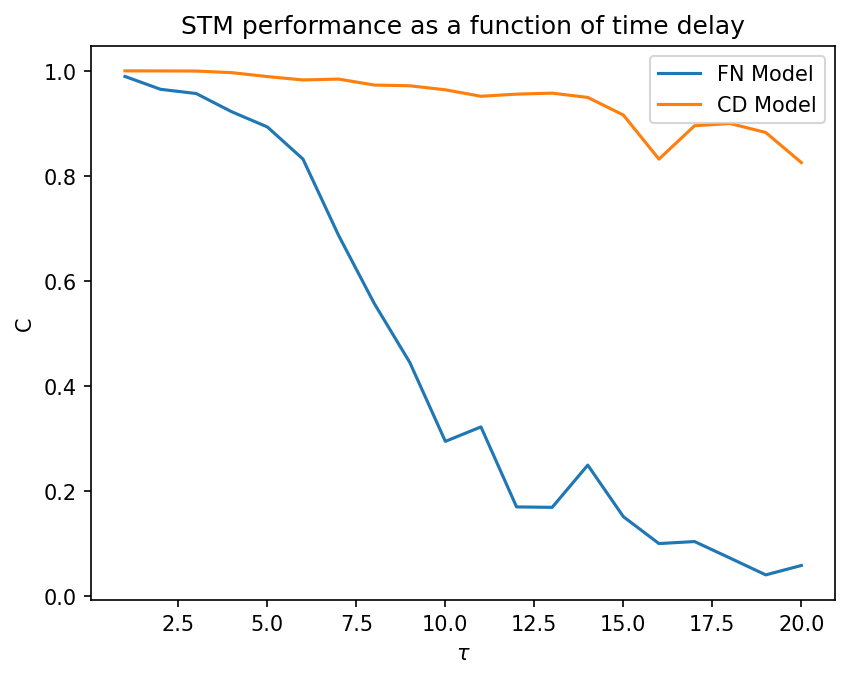

In [117]:
fig, ax = stm_task.plotPerfVsSettings(taus)
ax.set_xlabel(r'$\tau$')
ax.set_title('STM performance as a function of time delay')

#### 6.2.2 Performance on NARMA task

In [118]:
fn_narma_params = (1,1)
cd_narma_params = stmParamsCd(16)

In [119]:
n = 10
narma_task = RCTask(narma)

FN Capacity: 0.5590065330920003
CD Capacity: 0.7907633292569263


(<Figure size 960x720 with 1 Axes>, <Axes: xlabel='k'>)

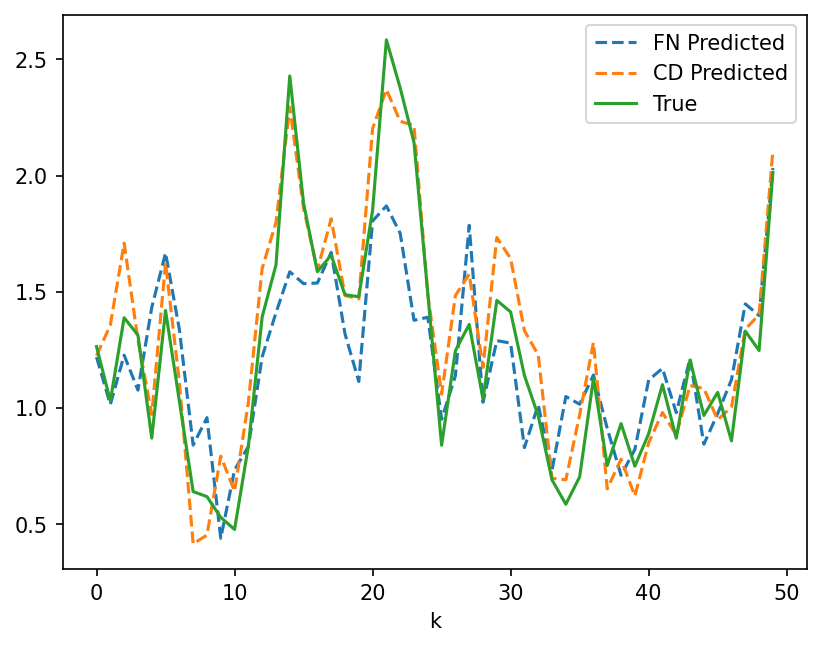

In [120]:
narma_task.plotTimeSeriesEstimate(n, fn_narma_params, cd_narma_params)

In [121]:
ns = np.arange(1, 21)

(<Figure size 960x720 with 1 Axes>, <Axes: ylabel='C'>)

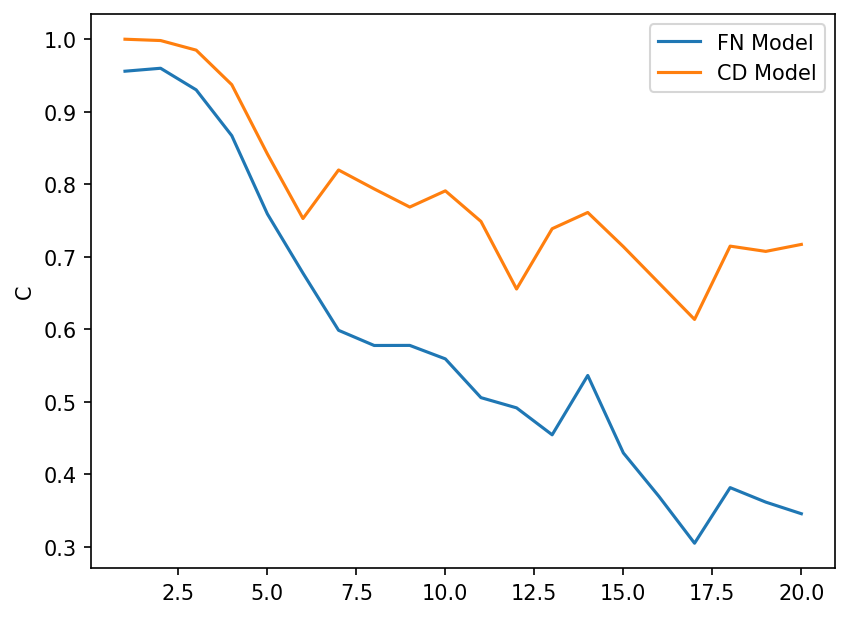

In [122]:
narma_task.plotPerfVsSettings(ns)

#### 6.2.3 Performance on Parity task

In [123]:
fn_parity_params = (1,1)
cd_parity_params = stmParamsCd(1)

In [124]:
ptau = 3
parity_task = RCTask(parity)

FN Capacity: 0.2964400640762326
CD Capacity: 0.14434677255037148


(<Figure size 960x720 with 1 Axes>, <Axes: xlabel='k'>)

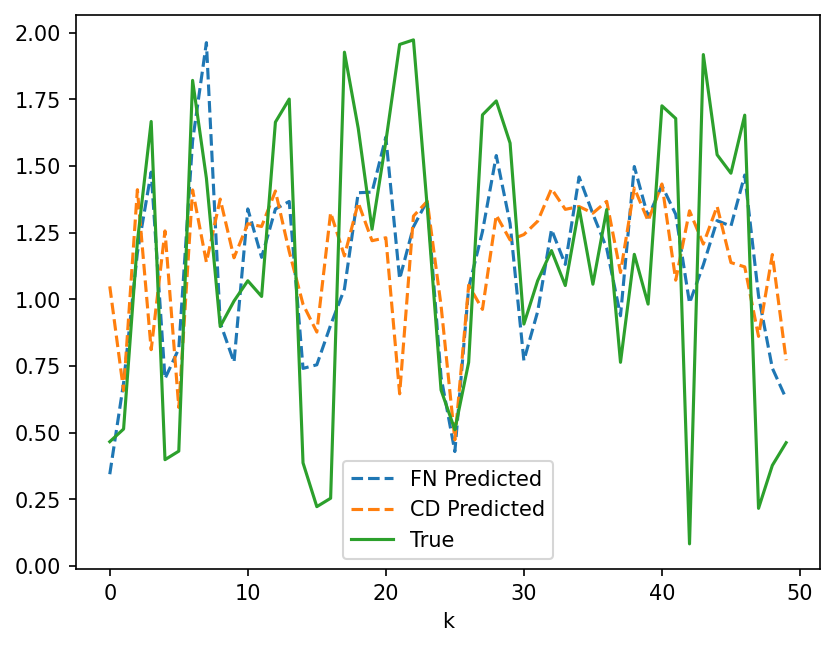

In [125]:
parity_task.plotTimeSeriesEstimate(ptau, fn_parity_params, cd_parity_params)

In [126]:
ptaus = np.arange(1, 6)

(<Figure size 960x720 with 1 Axes>, <Axes: ylabel='C'>)

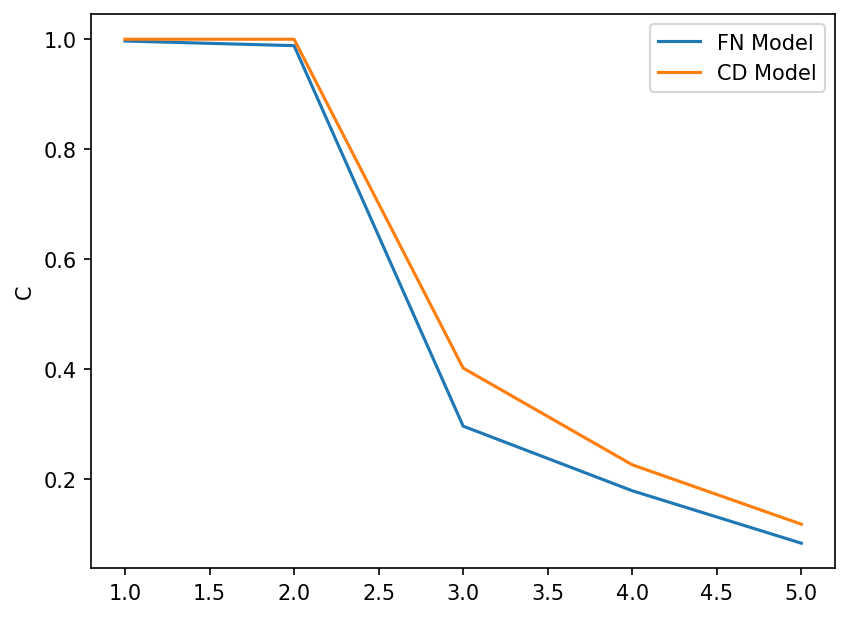

In [127]:
parity_task.plotPerfVsSettings(ptaus)

#### 6.2.4 Performance on Polynomial task

In [131]:
fn_poly_params = (1,1)
cd_poly_params = stmParamsCd(5)

In [132]:
n = 5
poly_task = RCTask(polynomial_exp)

FN Capacity: 0.9093881684509393
CD Capacity: 0.9786549845004063


(<Figure size 960x720 with 1 Axes>, <Axes: xlabel='k'>)

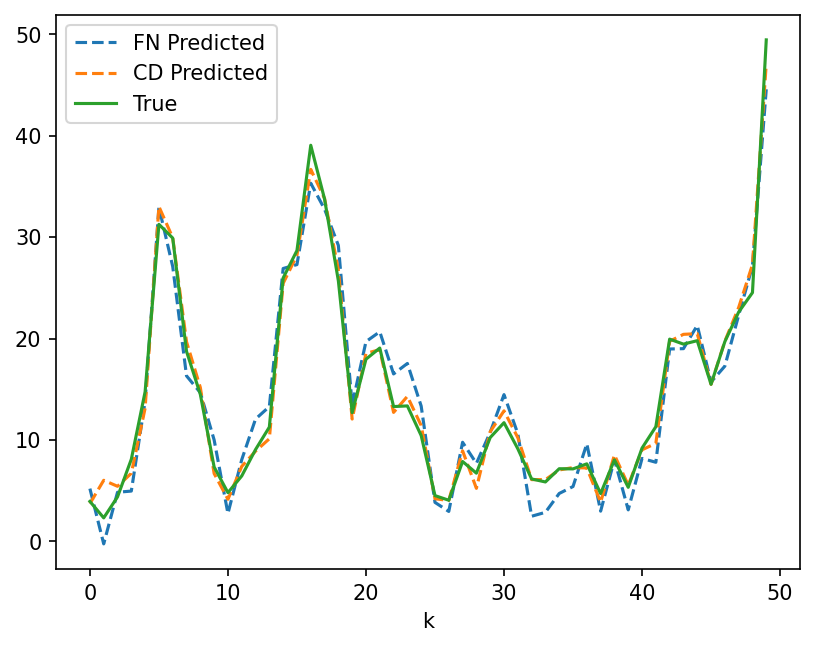

In [133]:
poly_task.plotTimeSeriesEstimate(n, fn_poly_params, cd_poly_params)

In [134]:
ns = np.arange(1, 21)

(<Figure size 960x720 with 1 Axes>, <Axes: ylabel='C'>)

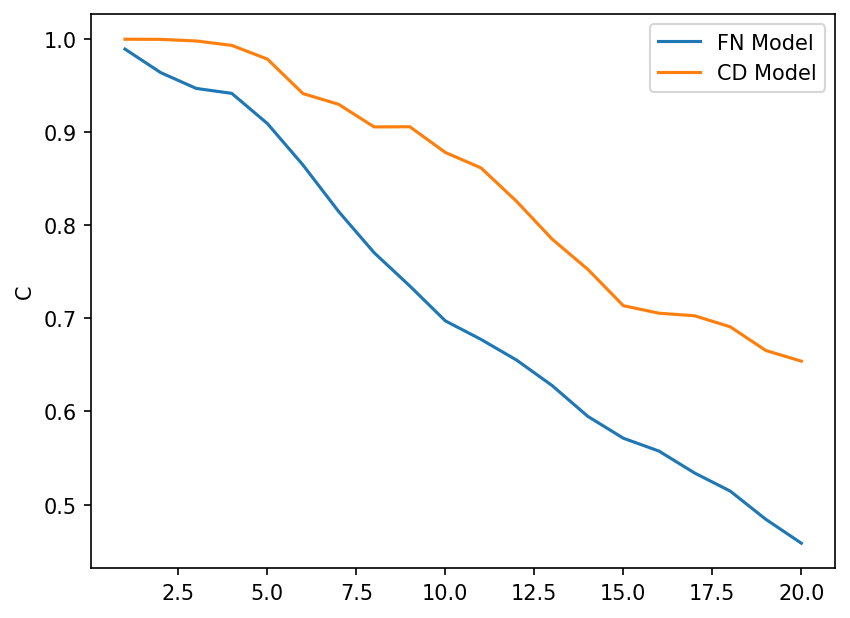

In [135]:
poly_task.plotPerfVsSettings(ns)

#### 6.2.5 Performance on Tomography task

In [136]:
fn_tomo_params = fn_params[1]
cd_tomo_params = cd_params[1]

In [137]:
n = 4
tomo_n = tomography(n, s)

In [138]:
y_tr_tomo, y_te_tomo = getYData(tomo_n)

In [139]:
reg_fn_tomo = LinearRegression().fit(x_tr_fn[fn_tomo_params], y_tr_tomo)
reg_cd_tomo = LinearRegression().fit(x_tr_cd[cd_tomo_params], y_tr_tomo)

In [140]:
y_pred_fn = reg_fn_tomo.predict(x_te_fn[fn_tomo_params])
y_pred_cd = reg_cd_tomo.predict(x_te_cd[cd_tomo_params])

In [141]:
rho_pred_fn = [DensityMatrix(vec_to_density_matrix(row)) for row in y_pred_fn]
rho_pred_cd = [DensityMatrix(vec_to_density_matrix(row)) for row in y_pred_cd]

rho_true = [DensityMatrix(vec_to_density_matrix(row)) for row in y_te_tomo]

In [142]:
import numpy as np
from scipy.linalg import sqrtm

def fidelity(rho, sigma):

    # sqrt(rho)
    sqrt_rho = sqrtm(rho)

    # sqrt(rho) sigma sqrt(rho)
    inner = sqrt_rho @ sigma @ sqrt_rho

    # sqrt of that
    sqrt_inner = sqrtm(inner)

    # trace
    F = np.trace(sqrt_inner)

    # Numerical noise can introduce tiny imaginary parts
    return float(np.real(F)**2)

In [143]:
fid_fn = np.mean([fidelity(state.state, state_pred.state) for state, state_pred in zip(rho_true, rho_pred_fn)])
fid_cd = np.mean([fidelity(state.state, state_pred.state) for state, state_pred in zip(rho_true, rho_pred_cd)])

/var/folders/8g/jdythvzn5njbj6km21j0m2080000gn/T/ipykernel_17159/3722345052.py:7: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sqrt_rho = sqrtm(rho)


In [144]:
print(f'Fidelity FN: {fid_fn}')
print(f'Fidelity CD: {fid_cd}')

Fidelity FN: 0.8592881743152908
Fidelity CD: 0.9297194301401996
